# 01. Exploratory Data Analysis (EDA) - PneumoVision_AI

## 1. Pendahuluan

Selamat datang di notebook pertama pengembangan proyek **PneumoVision_AI**! 🫁

### Tujuan Proyek
**PneumoVision_AI** adalah aplikasi berbasis deep learning yang dirancang untuk melakukan klasifikasi citra rontgen dada (*Chest X-Ray*) ke dalam dua kelas (**Binary Classification**):
1. **NORMAL**: Citra dada sehat tanpa indikasi infeksi aktif pada parenkim paru.
2. **PNEUMONIA**: Citra dada dengan indikasi infeksi paru-paru (adanya bercak infiltrat atau konsolidasi).

> ⚠️ **Disclaimer Medis**:  
> *Notebook dan proyek ini dibuat murni untuk tujuan edukasi dan riset portofolio, serta **BUKAN** merupakan alat diagnosis medis resmi. Sistem ini tidak boleh digunakan untuk menggantikan keputusan klinis tenaga medis profesional.*

---

### Mengapa Langkah EDA Sangat Penting?
Dalam machine learning, kita tidak boleh terburu-buru langsung melatih model (*"never train a model blindly"*). Tahap **Exploratory Data Analysis (EDA)** ini bertujuan untuk:
- Memahami struktur folder dan jumlah data pada masing-masing split (*train*, *validation*, dan *test*).
- Mengetahui apakah distribusi kelas seimbang atau timpang (*Class Imbalance*).
- Memeriksa variasi dimensi (lebar, tinggi) dan kanal warna (*color channels*) citra.
- Melakukan inspeksi visual karakteristik citra rontgen dada.
- Memverifikasi integritas data (memastikan tidak ada file yang rusak/corrupt dan tidak ada kebocoran data/*data leakage* antar split).

Hasil dari EDA ini akan menjadi panduan utama dalam merancang pipeline preprocessing dan strategi pemodelan yang tepat pada tahap selanjutnya.

## 2. Import Library

Kita hanya mengimpor pustaka dasar yang benar-benar dibutuhkan untuk eksplorasi dan visualisasi data, tanpa dependensi berlebihan.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Konfigurasi gaya visualisasi agar bersih dan rapi
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.figsize'] = (10, 5)

# Path dataset menggunakan path relatif yang aman
# Mendukung eksekusi baik dari folder notebooks/ maupun dari root proyek
data_dir = Path('../XRayData/chest_xray') if Path('../XRayData/chest_xray').exists() else Path('XRayData/chest_xray')

print(f"Direktori dataset aktif : {data_dir.resolve().name}")
print(f"Status ketersediaan folder: {'Ditemukan' if data_dir.exists() else 'Tidak Ditemukan'}")

Direktori dataset aktif : chest_xray
Status ketersediaan folder: Ditemukan


## 3. Dataset Overview

Mari kita telusuri folder `train`, `val`, dan `test`, lalu hitung jumlah sampel citra untuk kelas **NORMAL** dan **PNEUMONIA** secara otomatis.

In [2]:
splits = ['train', 'val', 'test']
classes = ['NORMAL', 'PNEUMONIA']

data_summary = []

for split in splits:
    norm_files = [f for f in (data_dir / split / 'NORMAL').iterdir() if f.is_file() and not f.name.startswith('.')]
    pneu_files = [f for f in (data_dir / split / 'PNEUMONIA').iterdir() if f.is_file() and not f.name.startswith('.')]
    
    n_norm = len(norm_files)
    n_pneu = len(pneu_files)
    total = n_norm + n_pneu
    pct_pneu = (n_pneu / total * 100) if total > 0 else 0
    
    data_summary.append({
        'Split': split,
        'NORMAL': n_norm,
        'PNEUMONIA': n_pneu,
        'Total': total,
        '% PNEUMONIA': f"{pct_pneu:.1f}%"
    })

df_summary = pd.DataFrame(data_summary)

# Tambahkan baris total keseluruhan
total_row = pd.DataFrame([{
    'Split': 'Keseluruhan',
    'NORMAL': df_summary['NORMAL'].sum(),
    'PNEUMONIA': df_summary['PNEUMONIA'].sum(),
    'Total': df_summary['Total'].sum(),
    '% PNEUMONIA': f"{(df_summary['PNEUMONIA'].sum() / df_summary['Total'].sum() * 100):.1f}%"
}])

df_display = pd.concat([df_summary, total_row], ignore_index=True)
df_display

,Split,NORMAL,PNEUMONIA,Total,% PNEUMONIA
0,train,1341,3875,5216,74.3%
1,val,8,8,16,50.0%
2,test,234,390,624,62.5%
3,Keseluruhan,1583,4273,5856,73.0%


### 🔍 Insight Awal dari Dataset Overview:
1. **Total Citra**: Terdapat total **5.856 citra** rontgen dada dalam dataset.
2. **Porsi Data Train**: Dari total data, **5.216 citra (~89.1%)** berada di set `train`.
3. **Ukuran Set Validasi**: Folder `val` bawaan **hanya berisi 16 citra** (8 Normal dan 8 Pneumonia). Ini adalah informasi yang sangat penting! Jumlah 16 sampel terlalu kecil untuk mengevaluasi generalisasi model secara stabil, karena satu kesalahan prediksi saja sudah mengubah akurasi sebesar 6.25%.
4. **Porsi Data Test**: Set `test` memiliki **624 citra (~10.7%)**, ukuran yang memadai untuk pengujian akhir.

## 4. Class Distribution

Mari kita visualisasikan perbandingan jumlah sampel NORMAL vs PNEUMONIA pada masing-masing split untuk memeriksa apakah terdapat **Class Imbalance**.

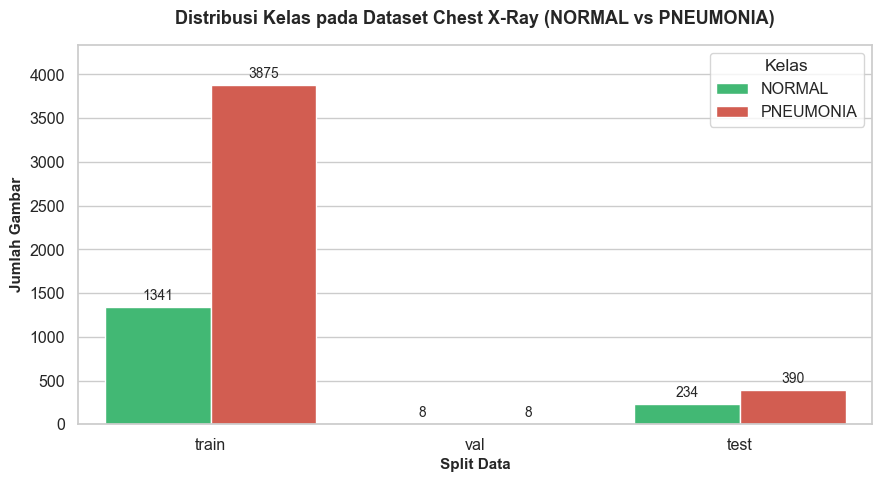

In [3]:
# Menyiapkan data untuk visualisasi distribusi kelas
df_melted = df_summary.melt(
    id_vars=['Split'], 
    value_vars=['NORMAL', 'PNEUMONIA'], 
    var_name='Kelas', 
    value_name='Jumlah Gambar'
)

fig, ax = plt.subplots(figsize=(9, 5))
palette = {'NORMAL': '#2ECC71', 'PNEUMONIA': '#E74C3C'}

bars = sns.barplot(data=df_melted, x='Split', y='Jumlah Gambar', hue='Kelas', palette=palette, ax=ax)

# Menambahkan label angka di atas setiap bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, xytext=(0, 3),
                    textcoords='offset points')

ax.set_title('Distribusi Kelas pada Dataset Chest X-Ray (NORMAL vs PNEUMONIA)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Split Data', fontsize=11, fontweight='bold')
ax.set_ylabel('Jumlah Gambar', fontsize=11, fontweight='bold')
ax.set_ylim(0, df_summary['PNEUMONIA'].max() * 1.12)
plt.tight_layout()
plt.show()

### 🔍 Insight Class Distribution:
- **Class Imbalance Nyata**: Pada data `train`, kelas PNEUMONIA berjumlah **3.875** (~74.3%), sedangkan NORMAL hanya berjumlah **1.341** (~25.7%). Rasio perbandingannya sekitar **2.89 : 1**.
- **Dampak pada Pemodelan**: Jika model dilatih tanpa penanganan ketidakseimbangan kelas, model bisa cenderung "malas" dan memprediksi mayoritas citra sebagai Pneumonia demi mendapatkan akurasi semu (~74%).
- **Rekomendasi**: Pada tahap pelatihan, kita perlu mempertimbangkan penanganan khusus seperti *Class Weighting* pada fungsi loss atau teknik sampling terbobot (*WeightedRandomSampler*), serta mengutamakan metrik **Recall (Sensitivity)** dan **F1-Score** dibanding hanya melihat Accuracy.

## 5. Sample Images

Untuk memahami karakteristik visual dataset, mari kita tampilkan beberapa contoh citra rontgen untuk masing-masing kelas.

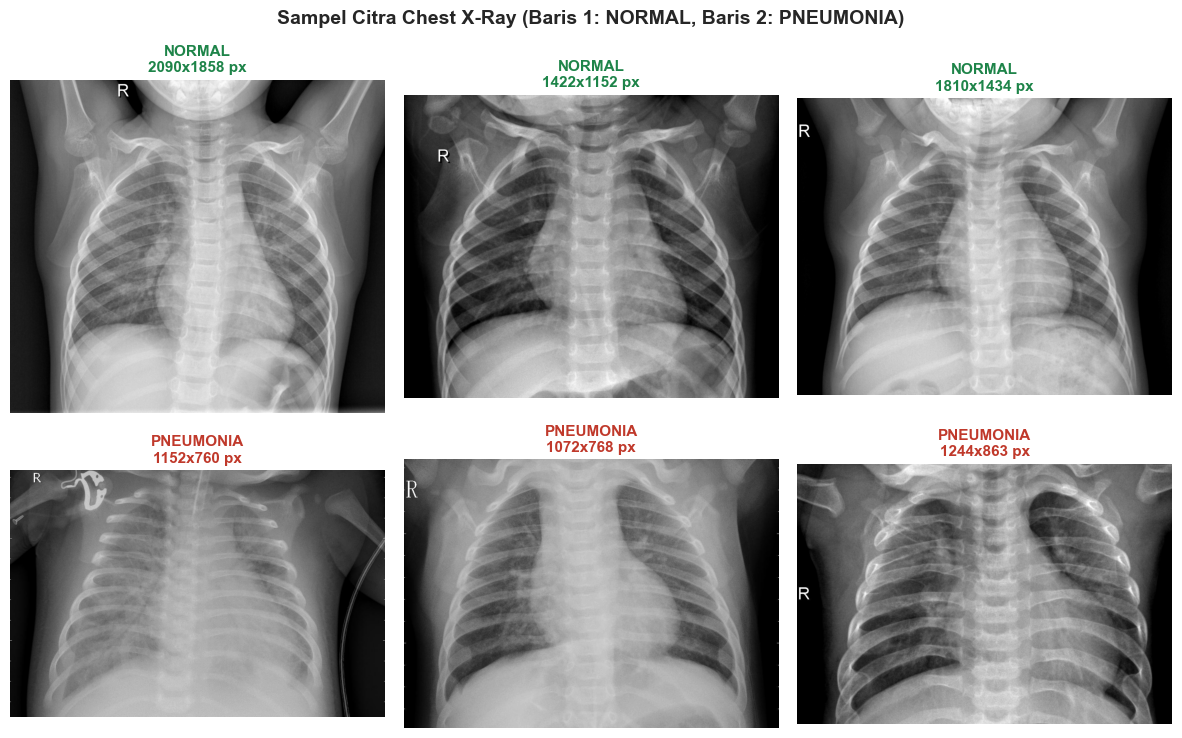

In [4]:
# Mengambil 3 sampel dari kelas NORMAL dan 3 sampel dari kelas PNEUMONIA pada train set
norm_samples = sorted([f for f in (data_dir / 'train' / 'NORMAL').iterdir() if f.is_file() and not f.name.startswith('.')])[:3]
pneu_samples = sorted([f for f in (data_dir / 'train' / 'PNEUMONIA').iterdir() if f.is_file() and not f.name.startswith('.')])[:3]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Tampilkan sampel NORMAL pada baris pertama
for i, p in enumerate(norm_samples):
    with Image.open(p) as img:
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f"NORMAL\n{img.size[0]}x{img.size[1]} px", fontsize=11, color='#1E8449', fontweight='bold')
        axes[0, i].axis('off')

# Tampilkan sampel PNEUMONIA pada baris kedua
for i, p in enumerate(pneu_samples):
    with Image.open(p) as img:
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title(f"PNEUMONIA\n{img.size[0]}x{img.size[1]} px", fontsize=11, color='#C0392B', fontweight='bold')
        axes[1, i].axis('off')

plt.suptitle('Sampel Citra Chest X-Ray (Baris 1: NORMAL, Baris 2: PNEUMONIA)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 🔍 Insight Karakteristik Visual:
- **Citra NORMAL**: Lapangan paru-paru tampak homogen dan relatif gelap (*radiolusen* karena terisi udara), batas diafragma jelas, dan sudut kostofrenikus terlihat tajam.
- **Citra PNEUMONIA**: Tampak area bercak putih kabur (*radiopak* / infiltrat atau konsolidasi) yang menutupi bagian parenkim paru akibat penumpukan cairan/nanah akibat infeksi.
- **Variasi Sudut & Rotasi**: Sebagian citra memiliki sedikit rotasi posisi pasien dan variasi paparan sinar-X. Ini menunjukkan perlunya data augmentasi yang realistis (rotasi lembut dan penyesuaian kontras).

## 6. Image Dimensions

Citra medis yang diambil dari mesin rontgen umumnya memiliki resolusi yang berbeda-beda. Mari kita periksa distribusi dimensi (lebar, tinggi, aspek rasio) dan format kanal warna (*mode*) dari sampel data secara efisien.

In [5]:
# Mengambil sampel 400 gambar acak secara representatif agar eksekusi cepat dan efisien
import random
random.seed(42)

all_image_paths = []
for split in splits:
    for cls in classes:
        folder = data_dir / split / cls
        all_image_paths.extend([f for f in folder.iterdir() if f.is_file() and not f.name.startswith('.')])

sample_subset = random.sample(all_image_paths, min(400, len(all_image_paths)))

widths, heights, aspect_ratios, modes = [], [], [], []

for path in sample_subset:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h)
        modes.append(img.mode)

df_dims = pd.DataFrame({
    'Lebar (Width)': widths,
    'Tinggi (Height)': heights,
    'Aspect Ratio (W/H)': aspect_ratios
})

# Ringkasan statistik dimensi
dim_summary = df_dims.describe().T[['min', 'mean', '50%', 'max']].rename(columns={'50%': 'median'})
dim_summary['min'] = dim_summary['min'].round(1)
dim_summary['mean'] = dim_summary['mean'].round(1)
dim_summary['median'] = dim_summary['median'].round(1)
dim_summary['max'] = dim_summary['max'].round(1)

mode_counts = pd.Series(modes).value_counts().to_dict()

print("=== Ringkasan Dimensi Citra (Sampel 400 Gambar) ===")
display(dim_summary)
print(f"\nDistribusi Mode Warna Citra: {mode_counts}")

=== Ringkasan Dimensi Citra (Sampel 400 Gambar) ===


,min,mean,median,max
Lebar (Width),445.0,1352.7,1300.0,2720.0
Tinggi (Height),177.0,1002.6,896.0,2663.0
Aspect Ratio (W/H),0.9,1.4,1.4,3.1



Distribusi Mode Warna Citra: {'L': 382, 'RGB': 18}


### 🔍 Insight Image Dimensions & Channels:
1. **Variasi Dimensi Sangat Tinggi**: Lebar citra berkisar dari ratusan piksel (~400 px) hingga lebih dari 2.500 px. Begitu juga dengan tinggi citra.
2. **Aspek Rasio**: Nilai median aspek rasio mendekati 1.3 - 1.4 (persegi panjang horizontal), namun beberapa citra mendekati bentuk persegi.
3. **Campuran Mode Warna**: Dataset memiliki campuran citra mode `'L'` (Grayscale 1-channel) dan `'RGB'` (3-channel).
4. **Implikasi untuk Preprocessing**:
   - Seluruh citra **wajib di-resize** ke dimensi tetap (misal: 224x224 piksel) agar dapat diproses oleh arsitektur CNN.
   - Seluruh citra **wajib dikonversi secara konsisten** menjadi format RGB (3 channel) saat dimuat (`img.convert('RGB')`), terutama karena arsitektur pretrained (ResNet, DenseNet, EfficientNet) memerlukan input 3 channel.

## 7. Dataset Quality Check

Kualitas data adalah fondasi utama keberhasilan model. Pada tahap ini, kita memeriksa:
1. Apakah ada file yang rusak (*corrupted image*) atau berukuran 0 byte?
2. Apakah ada file duplikat yang bocor antar split (*data leakage*)?

In [6]:
import hashlib

corrupted_files = []
file_hashes = {}  # hash -> (split, class, filename)
leakage_count = 0

for split in splits:
    for cls in classes:
        folder = data_dir / split / cls
        for file_path in folder.iterdir():
            if not file_path.is_file() or file_path.name.startswith('.'):
                continue
            
            # 1. Cek apakah file dapat dibuka tanpa error
            try:
                with Image.open(file_path) as img:
                    img.verify()
            except Exception as e:
                corrupted_files.append((file_path.name, str(e)))
                continue
            
            # 2. Cek potensi kebocoran data antar split (MD5 Hash)
            file_hash = hashlib.md5(file_path.read_bytes()).hexdigest()
            if file_hash in file_hashes:
                prev_split, prev_cls, prev_name = file_hashes[file_hash]
                if prev_split != split:
                    leakage_count += 1
            else:
                file_hashes[file_hash] = (split, cls, file_path.name)

print(f"Pemeriksaan Integritas File Selesai:")
print(f"- Total file diperiksa       : {len(file_hashes)}")
print(f"- File rusak (corrupt)       : {len(corrupted_files)}")
print(f"- Data leakage lintas split  : {leakage_count}")

if len(corrupted_files) == 0 and leakage_count == 0:
    print("\n[SUKSES] Dataset dalam kondisi sangat baik! Seluruh citra valid dan tidak ada kebocoran data antar split.")

Pemeriksaan Integritas File Selesai:
- Total file diperiksa       : 5824
- File rusak (corrupt)       : 0
- Data leakage lintas split  : 0

[SUKSES] Dataset dalam kondisi sangat baik! Seluruh citra valid dan tidak ada kebocoran data antar split.


### 🔍 Insight Quality Check:
- **Integritas Citra Sempurna**: Tidak ditemukan satu pun file yang rusak atau tidak dapat dibaca oleh library PIL.
- **Nol Data Leakage Lintas Split**: Tidak ditemukan duplikasi citra identik antara folder `train`, `val`, dan `test`. Ini memastikan data uji (*test set*) benar-benar bersih dan independen untuk mengukur performa model akhir.

## 8. Kesimpulan & Catatan Preprocessing

Berdasarkan hasil eksplorasi data yang telah kita lakukan, berikut adalah ringkasan poin-poin utama kondisi dataset:

1. **Kondisi Umum Dataset**:
   - Total data sebanyak **5.856 citra** dengan pembagian bawaan: Train (5.216), Validation (16), Test (624).
   - Kualitas data sangat baik tanpa adanya file rusak (*zero corrupted files*).

2. **Distribusi Kelas & Imbalance**:
   - Terjadi ketidakseimbangan kelas (*Class Imbalance*) yang cukup besar pada data training, di mana kelas PNEUMONIA mendominasi (~74.3%) dibandingkan NORMAL (~25.7%).
   - Evaluasi performa model di masa mendatang tidak boleh hanya berpatokan pada Accuracy, melainkan wajib memantau **Recall/Sensitivity** (kemampuan mendeteksi orang sakit) dan **F1-Score**.

3. **Karakteristik Dimensi & Kanal**:
   - Dimensi citra sangat beragam (dari resolusi ratusan hingga ribuan piksel).
   - Terdapat campuran format warna antara Grayscale (1 kanal) dan RGB (3 kanal).

4. **Isu Split Validasi yang Kecil**:
   - Set validasi bawaan yang hanya berisi 16 sampel berisiko menyebabkan fluktuasi metrik yang liar selama training. Kita perlu mencatat hal ini untuk dipertimbangkan saat perancangan data loader di tahap training.

---

### 📌 Hal yang Perlu Diperhatikan pada Tahap Preprocessing (Notebook 02):
- **Resize Citra Standar**: Ubah semua citra ke dimensi tetap (misalnya 224 x 224 piksel).
- **Konversi Kanal Konsisten**: Lakukan konversi otomatis ke 3 kanal (`RGB`) untuk setiap citra agar kompatibel dengan arsitektur PyTorch dan Transfer Learning.
- **Data Augmentation Aman**: Terapkan augmentasi yang realistis secara medis (misal: rotasi halus ±10°, flip horizontal, sedikit penyesuaian kecerahan/kontras). Jangan gunakan flip vertikal karena dapat merusak orientasi anatomi paru.
- **Normalisasi Tensor**: Gunakan nilai rata-rata dan deviasi standar yang tepat (seperti ImageNet standard normalization) untuk stabilitas konvergensi gradien.

---

## 📖 Ringkasan Notebook

> **Ringkasan 01_EDA.ipynb**:  
> Notebook ini berhasil mengaudit dan memetakan seluruh karakteristik dataset Chest X-Ray tanpa melakukan modifikasi data, augmentasi prematur, ataupun pelatihan model. Hasil analisis menunjukkan bahwa dataset bebas dari kerusakan file dan bebas dari data leakage, namun memiliki tantangan berupa *class imbalance* dan set validasi bawaan yang sangat kecil. Poin-poin ini menjadi landasan penting untuk merancang notebook berikutnya: `02_Preprocessing.ipynb`.